In [2]:
# Importing Library
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/opt/anaconda3/envs/python_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:



import pandas as pd

data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [
        ['excel', 'sql', 'python'],   # ✅ first list
        ['python', 'r'],              # ✅ second list
        ['aws', 'python', 'airflow']  # ✅ third list
    ]
}

df_skill_lists = pd.DataFrame(data)
print(df_skill_lists)


  job_title_short              job_skills
0    Data Analyst    [excel, sql, python]
1  Data Scientist             [python, r]
2   Data Engineer  [aws, python, airflow]


In [ ]:
df_skill_lists.explode('job_skills')

# explode function definiton

# One row with a list → becomes multiple rows (one value per row).

,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [5]:
df_skill_lists.explode('job_skills').value_counts('job_skills')

job_skills
python     3
airflow    1
aws        1
excel      1
r          1
sql        1
Name: count, dtype: int64

<Axes: xlabel='job_skills'>

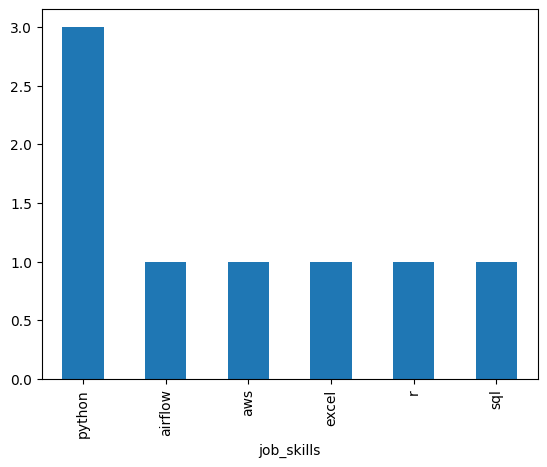

In [56]:
df_skill_lists.explode('job_skills').value_counts('job_skills').plot(kind = 'bar')

<Axes: xlabel='job_skills'>

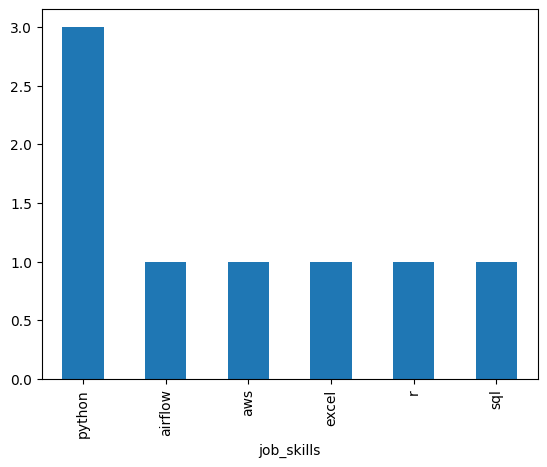

In [ ]:
# df_exploded = df.explode("job_skills").head(5)
# df_exploded.plot(kind='bar')
import ast

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
# above method is used to convert string into list
df_skill_lists.explode('job_skills').value_counts('job_skills').plot(kind='bar')

<Axes: xlabel='job_skills'>

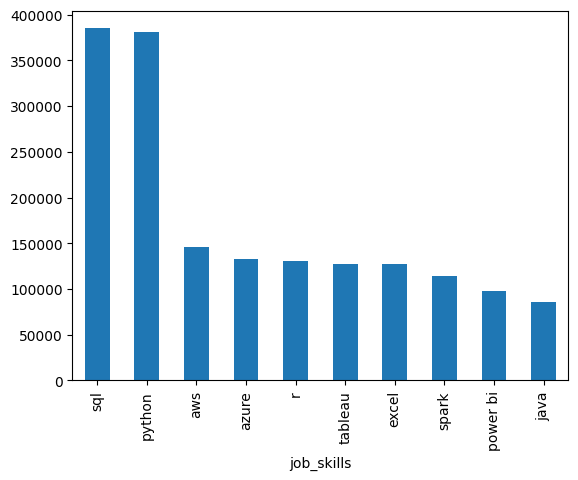

In [67]:
df_exploded = df.explode('job_skills')
skills_count = df_exploded.groupby(['job_title_short','job_skills']).size()
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')

In [68]:
skills_count = df_exploded.groupby(['job_title_short','job_skills']).size()
type(skills_count)

pandas.core.series.Series

In [69]:
df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)

# breaklist = df_skills_count.explode('job_skills')

# breaklist

df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


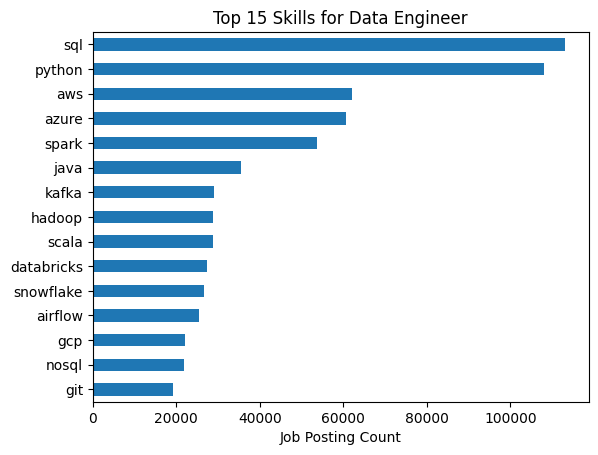

In [75]:
job_title = 'Data Engineer'
top_skills = 15

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

df_skill_final
df_skill_final.plot(kind='barh', x='job_skills', y='skill_count')

plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()